# Homework 5: Diagonalization, SVD and QR factorization

**Instructions**

(1) Once finished, upload your edited file (including solutions) after you have saved it as a pdf to [D2L](http://d2l.msu.edu/) with your answers on or before  **11:59 PM ET, Friday, April 17th, 2026**.

(2) Import a photo of your solutions or type in latex for the "BY HAND" problems. All the rest problems can be done by hand (type stuff on a markdown cell-not necessarily in Latex) or by code or even better by a combination of both. If you need to explain something and typing it is not easy, just write it on paper and import a photo.

**Always, make sure to JUSTIFY YOUR ANSWERS. Correct answers without justification, will be marked down.**

(3) Late HWs are not accepted.

In [22]:
import sympy as sym
import numpy as np

## Question 1 (25 points)

**<font color=red>QUESTION 1a:</font>** <font color=blue> **(BY HAND)** (11 points) Let $A=\begin{bmatrix} 6 & -2 & -1\\-2 & 6 & -1 \\ -1 & -1 & 5  \end{bmatrix}$. Write down a **singular value decomposition** of $A$ [Follow your instructor's notes; use python only for RREFs and matrix multiplications]. Describe your steps.
    
[Hint: $-x^3+109x^2-3204x+20736=-(x-9)(x-36)(x-64)$]

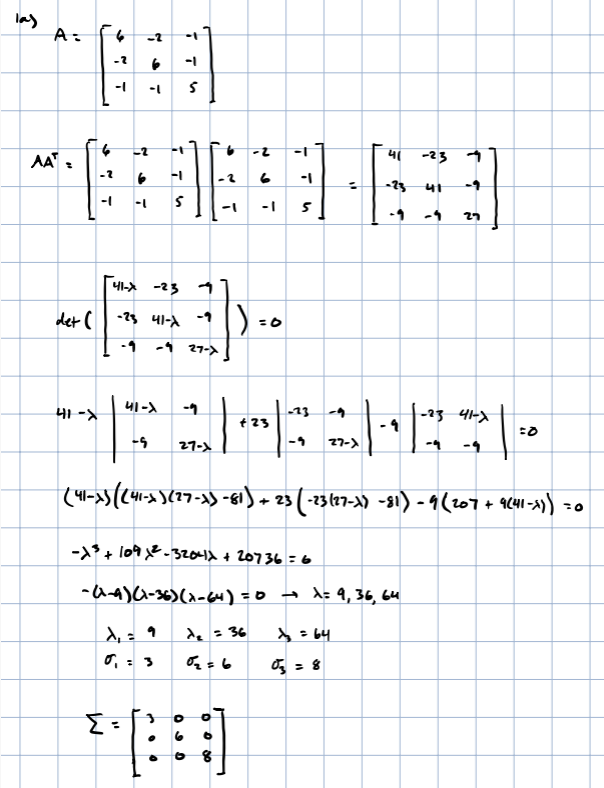

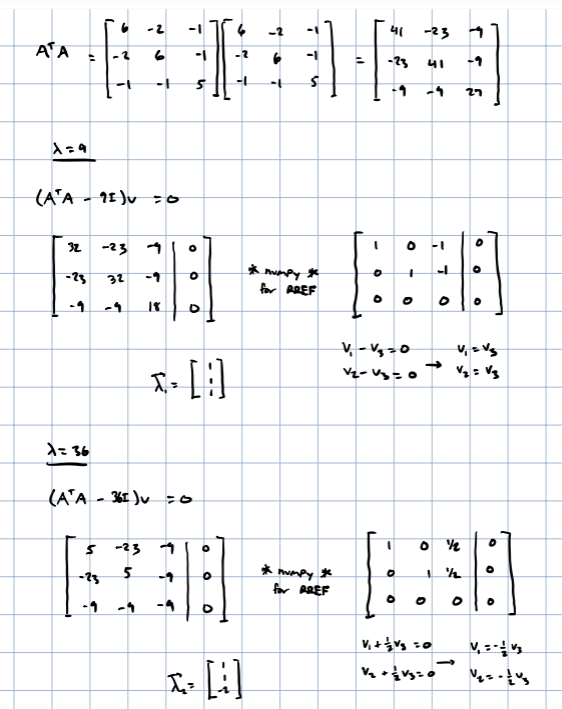

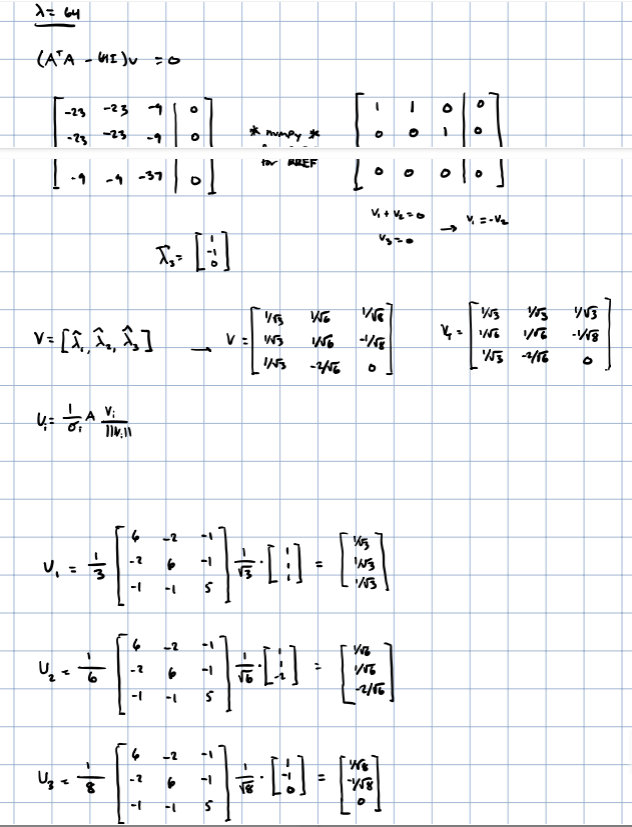

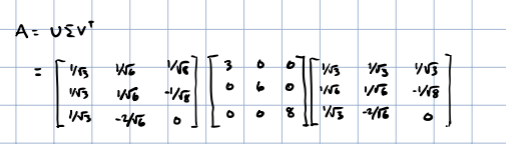

In [23]:
# solution
A = np.array([
    [6, -2, -1],
    [-2, 6, -1],
    [-1, -1, 5]
])

AAT = A @ A.T
ATA = A.T @ A
sym.Matrix(AAT)

Matrix([
[ 41, -23, -9],
[-23,  41, -9],
[ -9,  -9, 27]])

In [24]:
sym.Matrix(ATA)

Matrix([
[ 41, -23, -9],
[-23,  41, -9],
[ -9,  -9, 27]])

In [25]:
eig1 = np.diag((9,9,9))
eig2 = np.diag((36,36,36))
eig3 = np.diag((64,64,64))

In [26]:
sym.Matrix(ATA-eig1).rref()[0]

Matrix([
[1, 0, -1],
[0, 1, -1],
[0, 0,  0]])

In [27]:
sym.Matrix(ATA-eig2).rref()[0]

Matrix([
[1, 0, 1/2],
[0, 1, 1/2],
[0, 0,   0]])

In [28]:
sym.Matrix(ATA-eig3).rref()[0]

Matrix([
[1, 1, 0],
[0, 0, 1],
[0, 0, 0]])

In [29]:
eigvec1 = np.array([
    [1],
    [1],
    [1]
])

eigvec2 = np.array([
    [1],
    [1],
    [-2]
])

eigvec3 = np.array([
    [1],
    [-1],
    [0]
])

unit_eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
unit_eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
unit_eigvec3 = eigvec3 / np.linalg.norm(eigvec3)

sig1 = 3
sig2 = 6
sig3 = 8

u1 = 1/sig1 * (A @ unit_eigvec1)
u2 = 1/sig2 * (A @ unit_eigvec2)
u3 = 1/sig3 * (A @ unit_eigvec3)

U = np.concatenate((u1, u2, u3),axis=1)
V = np.concatenate((unit_eigvec1, unit_eigvec2, unit_eigvec3),axis=1)
big_sig = np.diag((sig1, sig2, sig3))

In [30]:
(U @ big_sig) @ V.T

array([[ 6., -2., -1.],
       [-2.,  6., -1.],
       [-1., -1.,  5.]])

Let's explore some more of the properties of $A$ to get an SVD for $A$ with a "different" method.

**<font color=red>QUESTION 1b:</font>**<font color=blue> **(BY HAND)** (3 points) Given that the characteristic equation of $A$ is $-(\lambda-8)(\lambda-6)(\lambda-3)=0$, find the eigenvalues and the corresponding eigenvectors. 

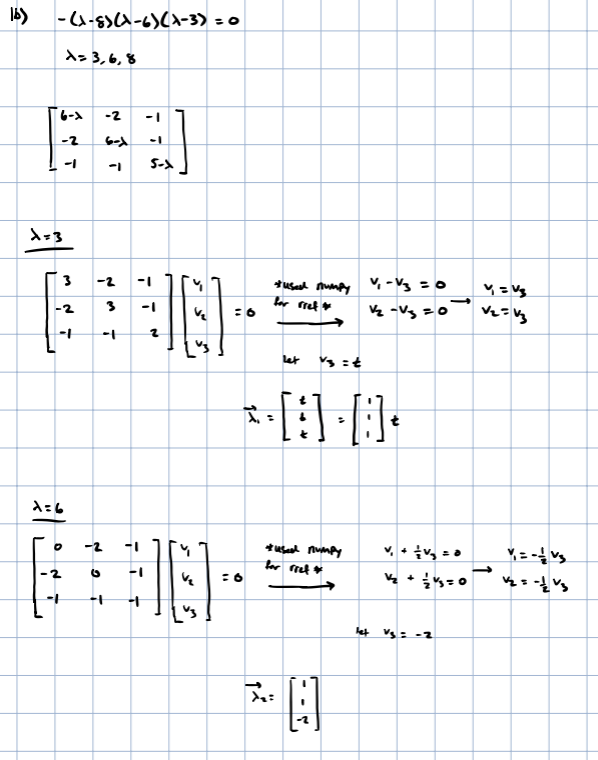

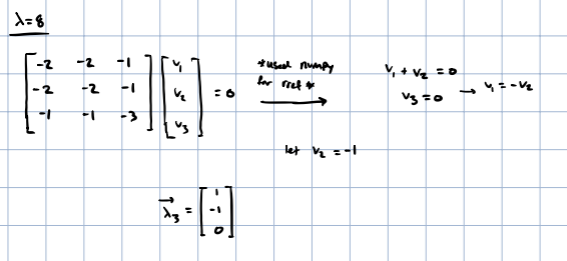

In [31]:
A = np.array([
    [6, -2, -1],
    [-2, 6, -1],
    [-1, -1, 5]
])

y3 = np.diag((3,3,3))
y6 = np.diag((6,6,6))
y8 = np.diag((8,8,8))

A3 = A - y3
A6 = A - y6
A8 = A - y8

In [32]:
sym.Matrix(A3).rref()[0]

Matrix([
[1, 0, -1],
[0, 1, -1],
[0, 0,  0]])

In [33]:
sym.Matrix(A6).rref()[0]

Matrix([
[1, 0, 1/2],
[0, 1, 1/2],
[0, 0,   0]])

In [34]:
sym.Matrix(A8).rref()[0]

Matrix([
[1, 1, 0],
[0, 0, 1],
[0, 0, 0]])

**<font color=red>QUESTION 1c:</font>**<font color=blue> (0.5 point)  Find a diagonalization for $A$.

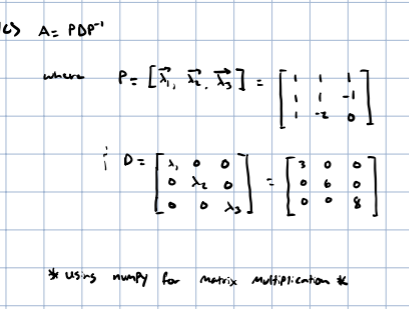

In [35]:
# solution
D = np.diag((3,6,8))
P = np.array([
    [1, 1, 1],
    [1, 1, -1],
    [1, -2, 0]
])

P_inv = np.linalg.inv(P)

A = (P@D) @ P_inv

sym.Matrix(A)

Matrix([
[ 6.0, -2.0, -1.0],
[-2.0,  6.0, -1.0],
[-1.0, -1.0,  5.0]])

**Matrix $D$**

In [36]:
sym.Matrix(D)

Matrix([
[3, 0, 0],
[0, 6, 0],
[0, 0, 8]])

**Matrix $P$**

In [37]:
sym.Matrix(P)

Matrix([
[1,  1,  1],
[1,  1, -1],
[1, -2,  0]])

**Matrix $P^{-1}$**

In [38]:
sym.Matrix(P_inv)

Matrix([
[0.333333333333333, 0.333333333333333,  0.333333333333333],
[0.166666666666667, 0.166666666666667, -0.333333333333333],
[              0.5,              -0.5,                0.0]])

**<font color=red>QUESTION 1d:</font>**<font color=blue> **(BY HAND)** (0.5 point)  Let $P$ be a matrix with columns the linearly eigenvectors you found in **1c**. Are the columns orthogonal to each other? Applying the Gram-Schmidt algorithm, if necessary, make the columns of $P$ **orthonormal**. Create a new matrix $W$ with the orthonormal columns.

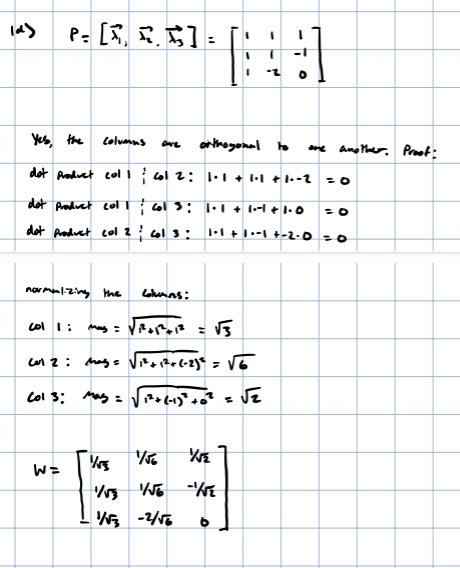

**<font color=red>QUESTION 1e:</font>**<font color=blue> (0.5 point) Now, write down an orthogonal diagonalization of $A$. 

In [40]:
P_norm = P.copy().astype(float)

P_norm[:,0] /= np.sqrt(3)
P_norm[:,1] /= np.sqrt(6)
P_norm[:,2] /= np.sqrt(2)

In [41]:
P_norm_inv = np.linalg.inv(P_norm)

In [42]:
A = (P_norm @ D) @ P_norm_inv
sym.Matrix(A)

Matrix([
[ 6.0, -2.0, -1.0],
[-2.0,  6.0, -1.0],
[-1.0, -1.0,  5.0]])

**Matrix $P$**

In [43]:
sym.Matrix(P_norm)

Matrix([
[0.577350269189626,  0.408248290463863,  0.707106781186547],
[0.577350269189626,  0.408248290463863, -0.707106781186547],
[0.577350269189626, -0.816496580927726,                0.0]])

**Matrix $D$**

In [44]:
sym.Matrix(D)

Matrix([
[3, 0, 0],
[0, 6, 0],
[0, 0, 8]])

**Matrix $P^{-1}$**

In [45]:
sym.Matrix(P_norm_inv)

Matrix([
[0.577350269189626,  0.577350269189626,  0.577350269189626],
[0.408248290463863,  0.408248290463863, -0.816496580927726],
[0.707106781186548, -0.707106781186548,                0.0]])

**<font color=red>QUESTION 1f:</font>**<font color=blue> (0.5 point) Write down a **singular value decomposition** of $A$, using Question **1d** and compare the result with Question **1a**.

In [46]:
U = P_norm
sigma = D
Vt = P_norm.T

result = U @ D @ Vt

sym.Matrix(result)

Matrix([
[ 6.0, -2.0, -1.0],
[-2.0,  6.0, -1.0],
[-1.0, -1.0,  5.0]])

**<font color=red>QUESTION 1g:</font>**<font color=blue> (4 points) Apply Gram-Schmidt algorithm to get an orthogonal basis for the column space $\text{col}(A)$. Then make this basis orthonormal.

In [47]:
def projection(v, u):
    u = np.array(u, dtype=float)
    v = np.array(v, dtype=float)
    if len(u) != len(v):
        raise ValueError("Vectors must have same dimension")

    y = np.dot(u, u)
    if y == 0:
        return np.zeros_like(u)   # or raise an error

    w = np.dot(v, u)
    return (w / y) * u

def GramSchmidt(A):
    A = np.array(A, dtype=float)
    AT = A.T
    GT = np.zeros_like(AT)

    for i in range(AT.shape[0]):
        ui = AT[i].copy()

        for j in range(i):
            uj = GT[j]
            if np.dot(uj, uj) != 0:
                ui -= projection(ui, uj)

        GT[i] = ui

    return GT.T

In [48]:
GS_A = GramSchmidt(A)
GS_A_norm = GS_A.copy()

GS_A_norm[:,0] /= np.linalg.norm(GS_A[:,0])
GS_A_norm[:,1] /= np.linalg.norm(GS_A[:,1])
GS_A_norm[:,2] /= np.linalg.norm(GS_A[:,2])

sym.Matrix(GS_A_norm)

Matrix([
[ 0.937042571331636,  0.257673560841309, 0.235702260395516],
[-0.312347523777212,  0.920262717290388, 0.235702260395516],
[-0.156173761888606, -0.294484069532924, 0.942809041582063]])

**<font color=red>QUESTION 1h:</font>**<font color=blue> (2 points) Using Question 1f, find a QR factorization for $A$, such that the matrix $Q$ is an orthonormal basis for the column space $\text{col}(A)$ and the matrix $R$ is upper triangular with positive entries on its diagonal.

In [49]:
# solution
q1 = A[:,0] / np.linalg.norm(A[:,0])
q2_p = A[:,1] - ((np.dot(A[:,1], q1) / np.dot(q1,q1)) * q1)
q2 = q2_p / np.linalg.norm(q2_p)
q3_p = A[:,2] - ((np.dot(A[:,2], q1) / np.dot(q1,q1)) * q1) - ((np.dot(A[:,2], q2) / np.dot(q2,q2)) * q2)
q3 = q3_p / np.linalg.norm(q3_p)

Q_p = np.concatenate((q1, q2, q3), axis=0)

Q = np.zeros((3,3))

k = 0
j = 0
for i in range(len(Q_p)):
    j = i
    if i < 3:
        Q[j,k] = Q_p[i]

    elif i >= 3 and i < 6:
        j -= 3
        k = 1
        Q[j,k] = Q_p[i]

    elif i >= 6:
        j -= 6
        k = 2
        Q[j,k] = Q_p[i]

In [50]:
R = np.round(Q.T @ A, 8)

**Matrix Q**

In [51]:
sym.Matrix(Q)

Matrix([
[ 0.937042571331636,  0.257673560841309, 0.235702260395516],
[-0.312347523777212,  0.920262717290388, 0.235702260395516],
[-0.156173761888606, -0.294484069532924, 0.942809041582063]])

**Matrix R**

In [52]:
sym.Matrix(R)

Matrix([
[6.40312424, -3.59199652, -1.40556386],
[       0.0,  5.30071325, -2.65035663],
[       0.0,         0.0,  4.24264069]])

**<font color=red>QUESTION 1i:</font>**<font color=blue> (3 points) Using Question 1g and back substitution, solve the system $Ax=b$, where $b=\begin{bmatrix}1\\-1\\0 \end{bmatrix}$ 

In [65]:
b = np.array([
    [1],
    [-1],
    [0]
])

Qb = Q.T @ b

Rx = np.concatenate((R, Qb), axis=1)

x = sym.Matrix(Rx).rref()[0][:, -1]

In [73]:
count = 1
for i in x:
    val = round(i, 3)
    print("x{} = {}".format(count, val))
    count += 1

x1 = 0.125
x2 = -0.125
x3 = 0.0


-----

## Before you close or submit this Homework, please make sure of two things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? For homeworks, you have to submit the file in `.pdf` format. 
 To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.

- Please make sure you submit the correct file filled-out file instead of an empty/blank file.

If you understand and agree that, print you name in the next code cell.

In [69]:
print("Mikel Good")

Mikel Good
